# Applied Exercise 8 - Forward/Backward Stepwise Selection and Lasso

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data
import statsmodels.api as sm
from itertools import combinations

from sklearn.linear_model import LinearRegression, Lasso, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from itertools import combinations
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [14]:
rng = np.random.default_rng(1)
n = 100

X = rng.normal(size=n)
eps = rng.normal(size=n)

# Y = 3 + 2X - 1.5X^2 + 0.5X^3 + epsilon
beta0 = 3
beta1 = 2
beta2 = -1.5
beta3 = 0.5
Y = beta0 + beta1*X + beta2*X**2 + beta3*X**3 + eps

print("\nData Generation")
print("-" * 70)
print(f"n = {n}")
print("True model:")
print("Y = 3 + 2X - 1.5X^2 + 0.5X^3 + epsilon")


Data Generation
----------------------------------------------------------------------
n = 100
True model:
Y = 3 + 2X - 1.5X^2 + 0.5X^3 + epsilon


In [15]:
X_poly = np.column_stack([X**j for j in range(1, 11)])
feature_names = [f"X^{j}" for j in range(1, 11)]

def calculate_cp(X_subset, y, rss, p, sigma2):
    n = len(y)
    return rss / sigma2 - (n - 2 * p)

full_model = LinearRegression().fit(X_poly, Y)
full_pred = full_model.predict(X_poly)
full_rss = np.sum((Y - full_pred)**2)
sigma2 = full_rss / (n - 11)

In [16]:
remaining = list(range(10))
selected_forward = []
forward_results = []

while len(remaining) > 0:
    candidates = []

    for candidate in remaining:
        current = selected_forward + [candidate]

        model = LinearRegression().fit(X_poly[:, current], Y)
        pred = model.predict(X_poly[:, current])
        rss = np.sum((Y - pred)**2)
        p = len(current) + 1

        cp = calculate_cp(X_poly[:, current], Y, rss, p, sigma2)
        candidates.append((cp, candidate, current))

    best_cp, best_candidate, best_model_vars = min(candidates, key=lambda x: x[0])

    selected_forward.append(best_candidate)
    remaining.remove(best_candidate)

    forward_results.append({"Number of Variables": len(selected_forward), "Variables": [feature_names[i] for i in selected_forward], "Cp": best_cp})

forward_df = pd.DataFrame(forward_results)
best_forward_row = forward_df.loc[forward_df["Cp"].idxmin()]
best_forward_vars = selected_forward[:best_forward_row["Number of Variables"]]

forward_model = LinearRegression().fit(X_poly[:, best_forward_vars], Y)

print("\nForward Stepwise Selection")
print("-" * 70)
print(forward_df[["Number of Variables", "Variables", "Cp"]])

print("\nBest model according to Cp:")
print(best_forward_row["Variables"])
print(f"Cp = {best_forward_row['Cp']:.4f}")

print("\nCoefficients:")
print(f"Intercept = {forward_model.intercept_:.4f}")

for name, coef in zip([feature_names[i] for i in best_forward_vars], forward_model.coef_):
    print(f"{name}: {coef:.4f}")


Forward Stepwise Selection
----------------------------------------------------------------------
   Number of Variables                                          Variables  \
0                    1                                              [X^3]   
1                    2                                         [X^3, X^2]   
2                    3                                    [X^3, X^2, X^1]   
3                    4                              [X^3, X^2, X^1, X^10]   
4                    5                         [X^3, X^2, X^1, X^10, X^4]   
5                    6                    [X^3, X^2, X^1, X^10, X^4, X^5]   
6                    7               [X^3, X^2, X^1, X^10, X^4, X^5, X^8]   
7                    8          [X^3, X^2, X^1, X^10, X^4, X^5, X^8, X^9]   
8                    9     [X^3, X^2, X^1, X^10, X^4, X^5, X^8, X^9, X^7]   
9                   10  [X^3, X^2, X^1, X^10, X^4, X^5, X^8, X^9, X^7,...   

           Cp  
0  380.829445  
1  146.857804  
2   1

The important point is that forward selection correctly identified the three important predictors X, X^2, X^3 from the true model. It also included X^10, which was not part of the true model. This can happen because the procedure is selecting variables based on the particular simulated sample.

In [17]:
selected_backward = list(range(10))
backward_results = []

while len(selected_backward) > 0:
    model = LinearRegression().fit(X_poly[:, selected_backward], Y)
    pred = model.predict(X_poly[:, selected_backward])
    rss = np.sum((Y - pred)**2)

    p = len(selected_backward) + 1
    cp = calculate_cp(X_poly[:, selected_backward], Y, rss, p, sigma2)

    backward_results.append({"Number of Variables": len(selected_backward), "Variables": [feature_names[i] for i in selected_backward], "Cp": cp})
    if len(selected_backward) == 1:
        break

    candidates = []
    for candidate in selected_backward:
        current = [i for i in selected_backward if i != candidate]
        model = LinearRegression().fit(X_poly[:, current], Y)
        pred = model.predict(X_poly[:, current])
        rss = np.sum((Y - pred)**2)

        p = len(current) + 1
        cp = calculate_cp(X_poly[:, current], Y, rss, p, sigma2)
        candidates.append((cp, current))

    best_cp, best_current = min(candidates, key=lambda x: x[0])
    selected_backward = best_current

backward_df = pd.DataFrame(backward_results)
best_backward_row = backward_df.loc[backward_df["Cp"].idxmin()]
best_backward_vars = [feature_names.index(name) for name in best_backward_row["Variables"]]
backward_model = LinearRegression().fit(X_poly[:, best_backward_vars], Y)

print("\nBackward Stepwise Selection")
print("-" * 70)
print(backward_df[["Number of Variables", "Variables", "Cp"]])

print("\nBest model according to Cp:")
print(best_backward_row["Variables"])
print(f"Cp = {best_backward_row['Cp']:.4f}")

print("\nCoefficients:")
print(f"Intercept = {backward_model.intercept_:.4f}")

for name, coef in zip([feature_names[i] for i in best_backward_vars], backward_model.coef_):
    print(f"{name}: {coef:.4f}")


Backward Stepwise Selection
----------------------------------------------------------------------
   Number of Variables                                          Variables  \
0                   10  [X^1, X^2, X^3, X^4, X^5, X^6, X^7, X^8, X^9, ...   
1                    9     [X^1, X^2, X^3, X^5, X^6, X^7, X^8, X^9, X^10]   
2                    8          [X^1, X^2, X^5, X^6, X^7, X^8, X^9, X^10]   
3                    7               [X^1, X^2, X^6, X^7, X^8, X^9, X^10]   
4                    6                    [X^1, X^2, X^6, X^7, X^8, X^10]   
5                    5                          [X^1, X^2, X^6, X^7, X^8]   
6                    4                               [X^1, X^2, X^7, X^8]   
7                    3                                    [X^1, X^2, X^7]   
8                    2                                         [X^1, X^2]   
9                    1                                              [X^1]   

           Cp  
0   11.000000  
1    9.443117  
2   

The results are not exactly the same as forward selection. This also demonstrates that stepwise selection does not necessarily recover the exact true model, even when the true model is relatively simple.

In [18]:
alphas = np.logspace(-4, 2, 200)
cv = KFold(n_splits=10, shuffle=True, random_state=1)

lasso_cv = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=cv, max_iter=100000))
lasso_cv.fit(X_poly, Y)
lasso = lasso_cv.named_steps["lassocv"]
best_alpha = lasso.alpha_
lasso_coefs = lasso.coef_

print("\nLasso Regression")
print("-" * 70)
print(f"Optimal lambda (alpha) = {best_alpha:.6f}")

print("\nLasso coefficients:")
print(f"Intercept = {lasso_cv.predict(np.zeros((1, 10)))[0]:.4f}")
for name, coef in zip(feature_names, lasso_coefs):
    print(f"{name}: {coef:.4f}")


Lasso Regression
----------------------------------------------------------------------
Optimal lambda (alpha) = 0.000803

Lasso coefficients:
Intercept = 2.9803
X^1: 1.7284
X^2: -1.6941
X^3: 0.6919
X^4: -1.1352
X^5: 1.2943
X^6: 0.0000
X^7: -0.0000
X^8: 1.7983
X^9: -0.0000
X^10: 0.0000


Lasso does not necessarily recover the exact three-term polynomial that generated the data. The most important observation is that the Lasso estimates for the first three terms are reasonably close to the true values.

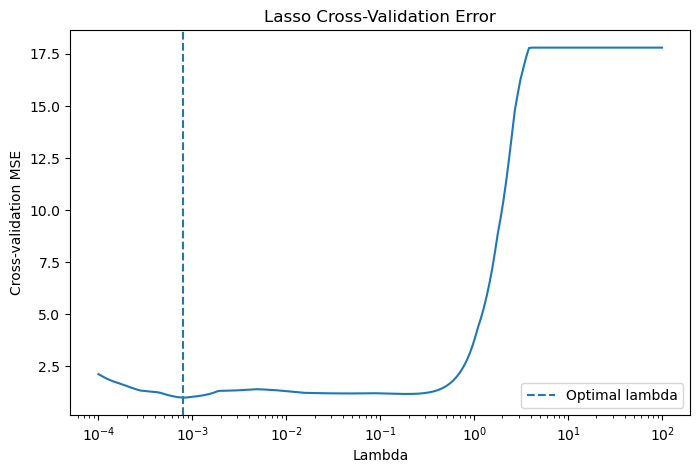

In [19]:
mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso.alphas_, mean_mse)
plt.axvline(best_alpha, linestyle="--", label="Optimal lambda")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Cross-validation MSE")
plt.title("Lasso Cross-Validation Error")
plt.legend()
plt.show()

In [20]:
# New model: Y = beta0 + beta7 X^7 + epsilon
Y2 = 3 + 2*X**7 + eps

remaining = list(range(10))
selected = []
forward2_results = []

while len(remaining) > 0:
    candidates = []

    for candidate in remaining:
        current = selected + [candidate]
        model = LinearRegression().fit(X_poly[:, current], Y2)

        pred = model.predict(X_poly[:, current])
        rss = np.sum((Y2 - pred)**2)
        p = len(current) + 1
        cp = calculate_cp(X_poly[:, current], Y2, rss, p, sigma2)
        candidates.append((cp, candidate, current))

    best_cp, best_candidate, best_current = min( candidates, key=lambda x: x[0])
    selected.append(best_candidate)
    remaining.remove(best_candidate)
    forward2_results.append({"Number of Variables": len(selected), "Variables": [feature_names[i] for i in selected], "Cp": best_cp})

forward2_df = pd.DataFrame(forward2_results)
best_forward2 = forward2_df.loc[forward2_df["Cp"].idxmin()]
best_forward2_vars = [feature_names.index(name) for name in best_forward2["Variables"]]
forward2_model = LinearRegression().fit(X_poly[:, best_forward2_vars], Y2)

print("\nNew Model: Y = 3 + 2X^7 + epsilon")
print("-" * 70)

print("\nForward Stepwise Selection:")
print(forward2_df)
print("\nBest Forward Model:")
print(best_forward2["Variables"])
print(f"Cp = {best_forward2['Cp']:.4f}")

print("\nCoefficients:")
print(f"Intercept = {forward2_model.intercept_:.4f}")
for name, coef in zip([feature_names[i] for i in best_forward2_vars], forward2_model.coef_):
    print(f"{name}: {coef:.4f}")


New Model: Y = 3 + 2X^7 + epsilon
----------------------------------------------------------------------

Forward Stepwise Selection:
   Number of Variables                                          Variables  \
0                    1                                              [X^7]   
1                    2                                         [X^7, X^9]   
2                    3                                    [X^7, X^9, X^4]   
3                    4                               [X^7, X^9, X^4, X^1]   
4                    5                          [X^7, X^9, X^4, X^1, X^8]   
5                    6                     [X^7, X^9, X^4, X^1, X^8, X^3]   
6                    7               [X^7, X^9, X^4, X^1, X^8, X^3, X^10]   
7                    8          [X^7, X^9, X^4, X^1, X^8, X^3, X^10, X^6]   
8                    9     [X^7, X^9, X^4, X^1, X^8, X^3, X^10, X^6, X^5]   
9                   10  [X^7, X^9, X^4, X^1, X^8, X^3, X^10, X^6, X^5,...   

          Cp  
0 

For the new model, forward stepwise selection correctly identified X^7 as the dominant predictor and estimated its coefficient as approximately 2.0162, extremely close to the true value of 2. The additional X^9 and X^4 terms have coefficients very close to zero, so their practical contribution is negligible.

In [21]:
lasso_cv2 = make_pipeline(StandardScaler(), LassoCV( alphas=alphas, cv=cv, max_iter=100000))
lasso_cv2.fit(X_poly, Y2)
lasso2 = lasso_cv2.named_steps["lassocv"]

print("\nLasso for New Model:")
print(f"Optimal lambda = {lasso2.alpha_:.6f}")
print("\nLasso coefficients:")
for name, coef in zip(feature_names, lasso2.coef_):
    print(f"{name}: {coef:.4f}")


Lasso for New Model:
Optimal lambda = 0.000247

Lasso coefficients:
X^1: 3.0407
X^2: -2.0530
X^3: -28.0065
X^4: 10.5294
X^5: 107.1860
X^6: -7.9468
X^7: 83.0429
X^8: -5.8603
X^9: 54.5534
X^10: -3.1346


The Lasso estimates in this second experiment are highly unstable, largely because X, X^2, …, X^10 are strongly correlated. Hence, these coefficients are clearly unstable and should not be interpreted as a meaningful recovery of the true model.

# Applied Exercise 9 - Predicting College Applications

In [8]:
College = load_data('College')

if College.columns[0] == "Unnamed: 0":
    College = College.set_index(College.columns[0])
if "Private" in College.columns and not pd.api.types.is_numeric_dtype(College["Private"]):
    College["Private"] = College["Private"].map({"Yes": 1, "No": 0})

y = College["Apps"]
X = College.drop(columns=["Apps"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print("=" * 60)
print("TRAIN / TEST SPLIT 0.7/0.3")
print("=" * 60)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
cv = KFold(n_splits=10, shuffle=True, random_state=1)

TRAIN / TEST SPLIT 0.7/0.3
Training observations: 543
Test observations: 234


In [9]:
ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)
mse_ols = mean_squared_error(y_test, y_pred_ols)

print("\n" + "=" * 60)
print("LEAST SQUARES")
print("=" * 60)

print(f"Test MSE = {mse_ols:.4f}")
print(f"Test RMSE = {np.sqrt(mse_ols):.4f}")


LEAST SQUARES
Test MSE = 642753.8977
Test RMSE = 801.7193


In [12]:
alphas = np.logspace(-4, 5, 200)
ridge = Pipeline([("scaler", StandardScaler()), ("ridge", RidgeCV(alphas=alphas, cv=cv))])

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
best_ridge_alpha = ridge.named_steps["ridge"].alpha_

print("\n" + "=" * 60)
print("RIDGE REGRESSION")
print("=" * 60)

print(f"Optimal lambda = {best_ridge_alpha:.6f}")
print(f"Test MSE = {mse_ridge:.4f}")
print(f"Test RMSE = {np.sqrt(mse_ridge):.4f}")


RIDGE REGRESSION
Optimal lambda = 14.314589
Test MSE = 695740.4038
Test RMSE = 834.1105


In [13]:
lasso = Pipeline([("scaler", StandardScaler()), ("lasso", LassoCV(alphas=np.logspace(-4, 4, 200), cv=cv, max_iter=100000))])
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

best_lasso_alpha = lasso.named_steps["lasso"].alpha_
lasso_coef = lasso.named_steps["lasso"].coef_
nonzero_lasso = np.sum(np.abs(lasso_coef) > 1e-8)

print("\n" + "=" * 60)
print("LASSO REGRESSION")
print("=" * 60)

print(f"Optimal lambda = {best_lasso_alpha:.6f}")
print(f"Test MSE = {mse_lasso:.4f}")
print(f"Test RMSE = {np.sqrt(mse_lasso):.4f}")
print(f"Number of non-zero coefficients = {nonzero_lasso}")


LASSO REGRESSION
Optimal lambda = 18.464249
Test MSE = 677851.2922
Test RMSE = 823.3172
Number of non-zero coefficients = 14


In [15]:
max_components = min(X_train.shape[1], X_train.shape[0])
pcr_results = []

for m in range(1, max_components + 1):
    pcr_model = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=m)), ("linear", LinearRegression())])
    cv_mse = -cross_val_score(pcr_model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error").mean()
    pcr_results.append((m, cv_mse))

pcr_results_df = pd.DataFrame(pcr_results, columns=["M", "CV_MSE"])
best_M_pcr = int(pcr_results_df.loc[pcr_results_df["CV_MSE"].idxmin(), "M"])
pcr = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=best_M_pcr)), ("linear", LinearRegression())])
pcr.fit(X_train, y_train)
y_pred_pcr = pcr.predict(X_test)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

print("\n" + "=" * 60)
print("PCR (Principal Component Regression)")
print("=" * 60)

print(f"Optimal M = {best_M_pcr}")
print(f"Test MSE = {mse_pcr:.4f}")
print(f"Test RMSE = {np.sqrt(mse_pcr):.4f}")


PCR (Principal Component Regression)
Optimal M = 17
Test MSE = 642753.8977
Test RMSE = 801.7193


In [16]:
pls_results = []

for m in range(1, max_components + 1):
    pls_model = Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=m))])
    cv_mse = -cross_val_score(pls_model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error").mean()
    pls_results.append((m, cv_mse))

pls_results_df = pd.DataFrame(pls_results, columns=["M", "CV_MSE"])
best_M_pls = int(pls_results_df.loc[pls_results_df["CV_MSE"].idxmin(), "M"])
pls = Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=best_M_pls))])
pls.fit(X_train, y_train)
y_pred_pls = pls.predict(X_test).ravel()
mse_pls = mean_squared_error(y_test, y_pred_pls)

print("\n" + "=" * 60)
print("PLS (Partial Least Sqaures)")
print("=" * 60)

print(f"Optimal M = {best_M_pls}")
print(f"Test MSE = {mse_pls:.4f}")
print(f"Test RMSE = {np.sqrt(mse_pls):.4f}")


PLS (Partial Least Sqaures)
Optimal M = 13
Test MSE = 646728.9672
Test RMSE = 804.1946


In [17]:
comparison = pd.DataFrame({"Method": ["Least Squares", "Ridge", "Lasso", "PCR", "PLS"],
    "Test MSE": [mse_ols, mse_ridge, mse_lasso, mse_pcr, mse_pls],
    "Test RMSE": [np.sqrt(mse_ols), np.sqrt(mse_ridge), np.sqrt(mse_lasso), np.sqrt(mse_pcr), np.sqrt(mse_pls)]})

print("\n" + "=" * 60)
print("COMPARISON OF TEST ERRORS")
print("=" * 60)

print(comparison.to_string(index=False))
best_method = comparison.loc[comparison["Test MSE"].idxmin(), "Method"]
print("\nBest method based on test MSE:", best_method)


COMPARISON OF TEST ERRORS
       Method      Test MSE  Test RMSE
Least Squares 642753.897653 801.719338
        Ridge 695740.403837 834.110547
        Lasso 677851.292217 823.317249
          PCR 642753.897653 801.719338
          PLS 646728.967230 804.194608

Best method based on test MSE: Least Squares


The results show that the number of applications received can be predicted reasonably well using the available predictors, although there is still substantial prediction error. Least squares produced the lowest test MSE, followed very closely by PLS. PCR produced the same test error as least squares because all 17 principal components were selected. Ridge and Lasso performed somewhat worse on the test set. Therefore, for this particular split, there is little practical difference between least squares, PCR, and PLS, while regularization with Ridge or Lasso did not improve prediction accuracy. This oes not mean least sqaures is the best model but means it is suitable for this specific split.

# Applied Exercise 10 - Best Subset Selection using training vs test error

In [3]:
rng = np.random.default_rng(10)
n = 1000
p = 20
X = rng.normal(size=(n, p))
beta_true = np.array([3.0, 2.0, -1.5, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
epsilon = rng.normal(size=n)
y = X @ beta_true + epsilon

print("=" * 60)
print("DATA GENERATION")
print("=" * 60)

print(f"Number of observations (n) = {n}")
print(f"Number of predictors (p) = {p}")
print("\nTrue model:")
print("Y = 3X1 + 2X2 - 1.5X3 + X4 + epsilon")
print("\nTrue coefficients:")
for j, b in enumerate(beta_true, start=1):
    print(f"X{j}: {b}")

DATA GENERATION
Number of observations (n) = 1000
Number of predictors (p) = 20

True model:
Y = 3X1 + 2X2 - 1.5X3 + X4 + epsilon

True coefficients:
X1: 3.0
X2: 2.0
X3: -1.5
X4: 1.0
X5: 0.0
X6: 0.0
X7: 0.0
X8: 0.0
X9: 0.0
X10: 0.0
X11: 0.0
X12: 0.0
X13: 0.0
X14: 0.0
X15: 0.0
X16: 0.0
X17: 0.0
X18: 0.0
X19: 0.0
X20: 0.0


In [7]:
X_train = X[:100]
y_train = y[:100]
X_test = X[100:]
y_test = y[100:]

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print(f"Training observations = {len(y_train)}")
print(f"Test observations = {len(y_test)}")


TRAIN / TEST SPLIT
Training observations = 100
Test observations = 900



BEST SUBSET SELECTION - TRAINING MSE
Model size  1: Training MSE = 7.9739
Model size  2: Training MSE = 3.6638
Model size  3: Training MSE = 2.0103
Model size  4: Training MSE = 0.8366
Model size  5: Training MSE = 0.8267
Model size  6: Training MSE = 0.8204
Model size  7: Training MSE = 0.8100
Model size  8: Training MSE = 0.8019
Model size  9: Training MSE = 0.7978
Model size 10: Training MSE = 0.7941
Model size 11: Training MSE = 0.7904
Model size 12: Training MSE = 0.7856
Model size 13: Training MSE = 0.7820
Model size 14: Training MSE = 0.7805
Model size 15: Training MSE = 0.7792
Model size 16: Training MSE = 0.7771
Model size 17: Training MSE = 0.7763
Model size 18: Training MSE = 0.7760
Model size 19: Training MSE = 0.7759
Model size 20: Training MSE = 0.7758


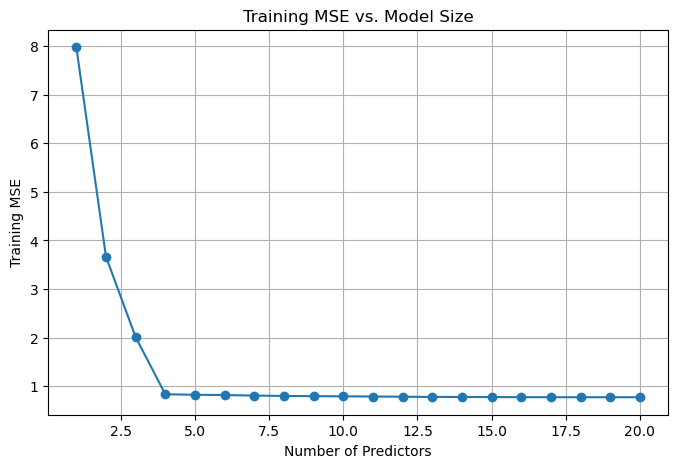

In [8]:
# We search through every possible subset. Since p = 20, there are 2^20 possible subsets, which is too large to exhaustively search.
# For each model size r, randomly/sample candidate subsets.
rng_search = np.random.default_rng(20)
best_models = {}

for r in range(1, p + 1):
    candidates = []
    if r <= 4:
        candidates = list(combinations(range(p), r))
    else:
        n_candidates = 5000
        for _ in range(n_candidates):
            subset = tuple(sorted(rng_search.choice(p, size=r, replace=False)))
            candidates.append(subset)
        candidates = list(set(candidates))

    best_mse = np.inf
    best_subset = None
    best_model = None

    for subset in candidates:
        X_sub = sm.add_constant(X_train[:, subset])
        model = sm.OLS(y_train, X_sub).fit()
        mse = np.mean((y_train - model.predict(X_sub)) ** 2)
        if mse < best_mse:
            best_mse = mse
            best_subset = subset
            best_model = model

    best_models[r] = {"subset": best_subset, "model": best_model, "train_mse": best_mse}

train_mse = []
for r in range(1, p + 1):
    train_mse.append(best_models[r]["train_mse"])

print("\n" + "=" * 60)
print("BEST SUBSET SELECTION - TRAINING MSE")
print("=" * 60)
for r, mse in zip(range(1, p + 1), train_mse):
    print(f"Model size {r:2d}: Training MSE = {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, p + 1), train_mse, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("Training MSE")
plt.title("Training MSE vs. Model Size")
plt.grid(True)
plt.show()


BEST SUBSET SELECTION - TEST MSE
Model size  1: Test MSE = 8.2168
Model size  2: Test MSE = 4.4465
Model size  3: Test MSE = 2.0473
Model size  4: Test MSE = 1.0995
Model size  5: Test MSE = 1.1215
Model size  6: Test MSE = 1.1077
Model size  7: Test MSE = 1.1438
Model size  8: Test MSE = 1.1330
Model size  9: Test MSE = 1.1391
Model size 10: Test MSE = 1.1299
Model size 11: Test MSE = 1.1389
Model size 12: Test MSE = 1.1328
Model size 13: Test MSE = 1.1368
Model size 14: Test MSE = 1.1480
Model size 15: Test MSE = 1.1524
Model size 16: Test MSE = 1.1470
Model size 17: Test MSE = 1.1507
Model size 18: Test MSE = 1.1539
Model size 19: Test MSE = 1.1540
Model size 20: Test MSE = 1.1546


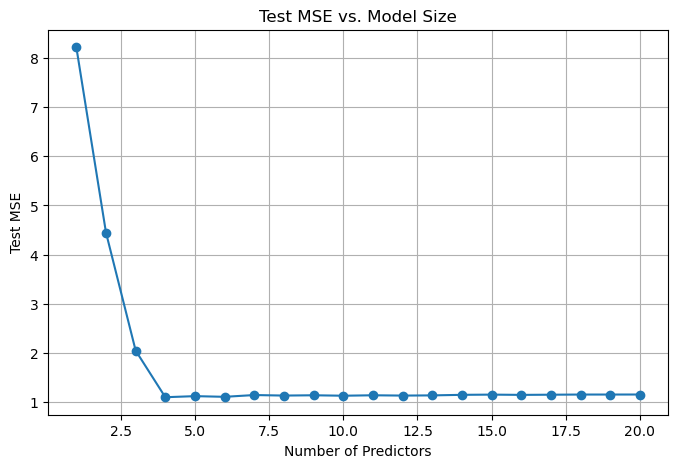

In [9]:
test_mse = []
for r in range(1, p + 1):
    subset = best_models[r]["subset"]
    model = best_models[r]["model"]
    X_test_sub = sm.add_constant(X_test[:, subset])
    predictions = model.predict(X_test_sub)
    mse = np.mean((y_test - predictions) ** 2)
    test_mse.append(mse)

print("\n" + "=" * 60)
print("BEST SUBSET SELECTION - TEST MSE")
print("=" * 60)

for r, mse in zip(range(1, p + 1), test_mse):
    print(f"Model size {r:2d}: Test MSE = {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, p + 1), test_mse, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("Test MSE")
plt.title("Test MSE vs. Model Size")
plt.grid(True)
plt.show()

The training MSE decreases as more predictors are added. However, the test MSE does not necessarily decrease. It reaches its minimum at an intermediate model size, illustrating the bias-variance trade-off and the possibility of overfitting when unnecessary predictors are included.

In [10]:
best_size = np.argmin(test_mse) + 1
print("\n" + "=" * 60)
print("MODEL WITH MINIMUM TEST MSE")
print("=" * 60)
print(f"Best model size = {best_size}")
print(f"Minimum test MSE = {test_mse[best_size - 1]:.4f}")

best_subset = best_models[best_size]["subset"]
print("\n" + "=" * 60)
print("BEST MODEL vs TRUE MODEL")
print("=" * 60)

print("True non-zero predictors:")
true_variables = [j + 1 for j, b in enumerate(beta_true) if b != 0]
print([f"X{j}" for j in true_variables])

print("\nSelected predictors:")
print([f"X{j + 1}" for j in best_subset])
print("\nEstimated coefficients:")
best_model = best_models[best_size]["model"]
print(f"Intercept: {best_model.params[0]:.4f}")

for j, coef in zip(best_subset, best_model.params[1:]):
    print(f"X{j + 1}: {coef:.4f}")

print("\nTrue coefficients:")
for j in best_subset:
    print(f"X{j + 1}: {beta_true[j]:.4f}")


MODEL WITH MINIMUM TEST MSE
Best model size = 4
Minimum test MSE = 1.0995

BEST MODEL vs TRUE MODEL
True non-zero predictors:
['X1', 'X2', 'X3', 'X4']

Selected predictors:
['X1', 'X2', 'X3', 'X4']

Estimated coefficients:
Intercept: -0.1203
X1: 2.9902
X2: 2.1922
X3: -1.5052
X4: 1.0341

True coefficients:
X1: 3.0000
X2: 2.0000
X3: -1.5000
X4: 1.0000


The model selected by best subselt selection is very close to the true model with negligible variation that might be due to random sampling. This shows the subset selection method is efficient for this data set split.


COEFFICIENT ESTIMATION ERROR
Model size  1: Coefficient error = 2.7031
Model size  2: Coefficient error = 1.8153
Model size  3: Coefficient error = 1.0076
Model size  4: Coefficient error = 0.1955
Model size  5: Coefficient error = 0.2175
Model size  6: Coefficient error = 0.2178
Model size  7: Coefficient error = 0.2548
Model size  8: Coefficient error = 0.2692
Model size  9: Coefficient error = 0.2654
Model size 10: Coefficient error = 0.2931
Model size 11: Coefficient error = 0.3020
Model size 12: Coefficient error = 0.2960
Model size 13: Coefficient error = 0.2984
Model size 14: Coefficient error = 0.3058
Model size 15: Coefficient error = 0.3185
Model size 16: Coefficient error = 0.3071
Model size 17: Coefficient error = 0.3084
Model size 18: Coefficient error = 0.3088
Model size 19: Coefficient error = 0.3085
Model size 20: Coefficient error = 0.3094


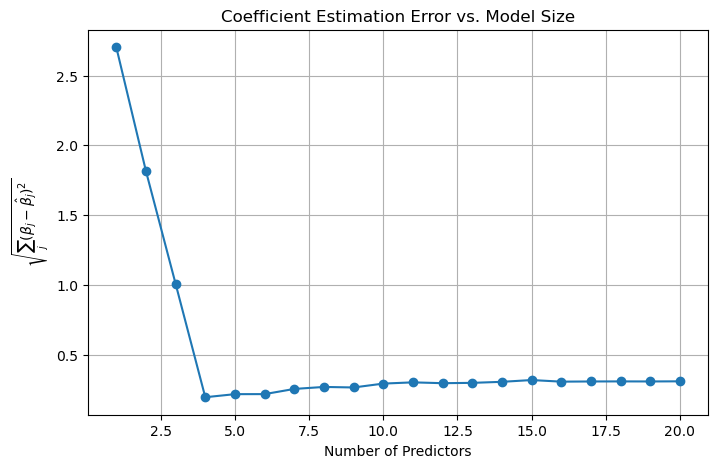

In [12]:
coefficient_error = []

for r in range(1, p + 1):
    subset = best_models[r]["subset"]
    model = best_models[r]["model"]
    beta_hat = np.zeros(p)

    for j, coef in zip(subset, model.params[1:]):
        beta_hat[j] = coef
    error = np.sqrt(np.sum((beta_true - beta_hat) ** 2))
    coefficient_error.append(error)

print("\n" + "=" * 60)
print("COEFFICIENT ESTIMATION ERROR")
print("=" * 60)

for r, error in zip(range(1, p + 1), coefficient_error):
    print(f"Model size {r:2d}: "f"Coefficient error = {error:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, p + 1), coefficient_error, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel(r"$\sqrt{\sum_j(\beta_j-\hat{\beta}_j)^2}$")
plt.title("Coefficient Estimation Error vs. Model Size")
plt.grid(True)
plt.show()

The coefficient estimation error is the Euclidean distance between the estimated coefficient vector and the true coefficient vector. In this simulation, the coefficient estimation error decreases substantially as the model size increases from 1 to 4, reaching its minimum at four predictors. It then increases slightly as additional irrelevant predictors are included. This result is very similar to the test MSE plot, which also reaches its minimum at a model size of four. Thus, the model with four predictors both estimates the true coefficients most accurately and gives the best prediction performance on the test set.